Final calculated mean of p(x): 0.02195
Final calculated std of p(x) = 1.71929


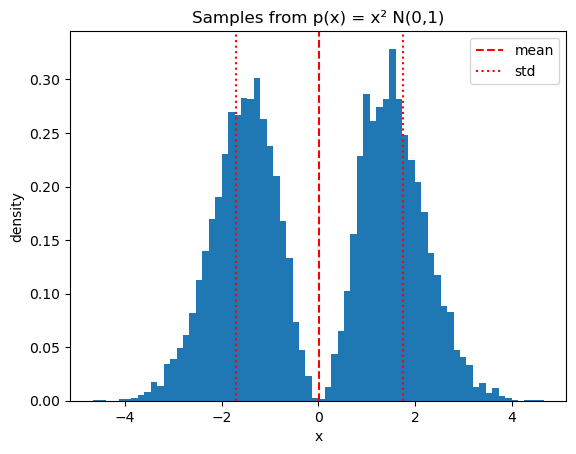

In [23]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

N = 10000
mean = 0
std = 1

# -- Generate random data, using built-in numpy func --
random = np.random.normal(mean, std, size=(N,3))
length = np.sum(random**2, axis=1) # length of gaussian vector
result = np.sqrt(length) # length of gaussian vector is chi distribution with 3 dof

signs = np.random.choice(a=[-1, 1], size=N) # because of std = 1 and mean = 0 
final = signs * result

mean_final = np.mean(final)
std_final = np.std(final)

print(f"Final calculated mean of p(x): {round(mean_final, 5)}")
print(f"Final calculated std of p(x) = {round(std_final, 5)}")

plt.hist(final, bins=70, density=True)
plt.title("Samples from p(x) = x² N(0,1)")
plt.axvline(mean_final, linestyle='--', label='mean', color='red')
plt.axvline(mean_final + std_final,linestyle=':', label='std', color='red')
plt.axvline(mean_final - std_final, linestyle=':', color='red')
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()


Resampled mean of p(x)|z=0.5: 0.48486
Resampled std of p(x)|z=0.5: 0.29861


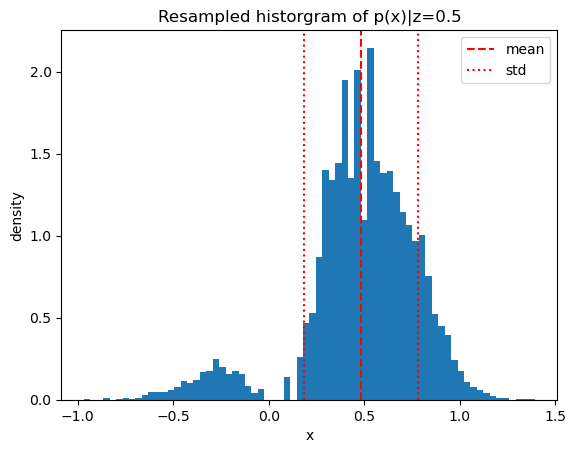

In [25]:
# task b

# e = np.random.normal(0, 0.3), z = 2x + e
# Measured z = 0.5
# std = sqrt(var^2)

z = 0.5
var = 0.3

# -- Likelihood weights --
log_weights = -0.5 * (z - 2*final)**2 / var # avoids underflow issues
weights = np.exp(log_weights - np.max(log_weights)) # normalize weights, max log weight is 0 => max weight is 1, relative weights are preserved
weights /= np.sum(weights) # normalize weights to sum to 1, required for probability distribution and resampling
# Converts weights into probabilities

# -- Resampling --
resampled_indicies = np.random.choice(a=np.arange(N), size=N, replace=True, p=weights)
resampled_final = final[resampled_indicies]
resampled_mean = np.mean(resampled_final)
resampled_std = np.std(resampled_final)

print(f"Resampled mean of p(x)|z=0.5: {round(resampled_mean, 5)}")
print(f"Resampled std of p(x)|z=0.5: {round(resampled_std, 5)}")

# -- Plotting --
plt.hist(resampled_final, bins=70, density=True)
plt.title("Resampled historgram of p(x)|z=0.5")
plt.axvline(resampled_mean, linestyle='--', label='mean', color='red')
plt.axvline(resampled_mean + resampled_std, linestyle=':', label='std', color='red')
plt.axvline(resampled_mean - resampled_std, linestyle=':', color='red')
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()
